In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import seaborn as sns
import geopandas as gpd
import plotly.express as px

In [3]:
pip install shapely fiona pyproj rtree

Note: you may need to restart the kernel to use updated packages.


In [74]:
#pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.4 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.7 MB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.


In [76]:
#pip install geopandas


   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/22.9 MB 4.2 MB/s eta 0:00:06
   --- ------------------------------------ 2.1/22.9 MB 4.2 MB/s eta 0:00:05
   ----- ---------------------------------- 3.1/22.9 MB 4.1 MB/s eta 0:00:05
   ------- -------------------------------- 4.2/22.9 MB 4.1 MB/s eta 0:00:05
   -------- ------------------------------- 5.0/22.9 MB 4.1 MB/s eta 0:00:05
   ---------- ----------------------------- 6.3/22.9 MB 4.2 MB/s eta 0:00:04
   ------------ --------------------------- 7.3/22.9 MB 4.1 MB/s eta 0:00:04
   ------------- -------------------------- 7.9/22.9 MB 3.9 MB/s eta 0:00:04
   --------------- ------------------------ 8.9/22.9 MB 3.8 MB/s eta 0:00:04
   ---------------- ----------------------- 9.4/22.9 MB 3.7 MB/s eta 0:00:04
   ----------------- ---------------------- 10.2/22.9 MB 3.6 MB/s eta 0:00:04
   ------------------- -------------------- 11.0/22.9 MB 3.5 MB/s eta 0:00:04
   

In [5]:
#conda install -c conda-forge geopandas

In [71]:
conda install -c conda-forge geopandas rasterio shapely fiona pyproj

^C

Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

In [9]:
#pip install xgboost

## Load Dataset



In [12]:
data = pd.read_csv(r"C:\Users\funmi\Downloads\MAPLE\InterDisciplinary studies\AgroIntelliJ\wheat_data.csv")

print(data.head())

    Latitude  Longitude  apparentTemperatureMax  apparentTemperatureMin  \
0  31.659157  72.341565               44.072192               29.264916   
1  24.552223  83.651481               33.811489               29.188423   
2  25.053288  72.861068               22.020405               12.163084   
3  36.091315  72.719879               41.994364               28.916630   
4  18.960587  79.651551               35.074907               12.321231   

   cloudCover   dewPoint  humidity  precipIntensity  precipIntensityMax  \
0    0.356576  17.301551  0.765369         0.199313            1.552217   
1    0.406334  16.531581  0.782977         4.887975            1.749305   
2    0.813958  18.337718  0.640384         4.381282            2.608996   
3    0.751695  17.915672  0.357538         0.520668            1.723544   
4    0.675791  12.468106  0.494761         1.714945            3.272974   

   precipProbability  ...  precipTypeIsOther     pressure  temperatureMax  \
0           0.668593 

In [14]:
data.shape

(200000, 23)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Latitude                200000 non-null  float64
 1   Longitude               200000 non-null  float64
 2   apparentTemperatureMax  200000 non-null  float64
 3   apparentTemperatureMin  200000 non-null  float64
 4   cloudCover              200000 non-null  float64
 5   dewPoint                200000 non-null  float64
 6   humidity                200000 non-null  float64
 7   precipIntensity         200000 non-null  float64
 8   precipIntensityMax      200000 non-null  float64
 9   precipProbability       200000 non-null  float64
 10  precipAccumulation      200000 non-null  float64
 11  precipTypeIsRain        200000 non-null  int64  
 12  precipTypeIsSnow        200000 non-null  int64  
 13  precipTypeIsOther       200000 non-null  int64  
 14  pressure            

#### Observation

In [19]:
data.isnull().sum()

Latitude                  0
Longitude                 0
apparentTemperatureMax    0
apparentTemperatureMin    0
cloudCover                0
dewPoint                  0
humidity                  0
precipIntensity           0
precipIntensityMax        0
precipProbability         0
precipAccumulation        0
precipTypeIsRain          0
precipTypeIsSnow          0
precipTypeIsOther         0
pressure                  0
temperatureMax            0
temperatureMin            0
visibility                0
windBearing               0
windSpeed                 0
NDVI                      0
DayInSeason               0
Yield                     0
dtype: int64

## Statistics

In [22]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,200000.0,22.477387,8.369017,8.000068,15.216047,22.485451,29.715143,36.999972
Longitude,200000.0,82.511188,8.359161,68.000020,75.280052,82.538473,89.718761,96.999965
apparentTemperatureMax,200000.0,32.498709,7.198028,20.000007,26.276031,32.500039,38.726467,44.999977
apparentTemperatureMin,200000.0,20.007869,5.770943,10.000216,15.028456,19.992886,24.986128,29.999763
cloudCover,200000.0,0.500812,0.288576,0.000010,0.251240,0.500629,0.750860,0.999994
dewPoint,200000.0,17.496816,4.329797,10.000035,13.736282,17.505235,21.239095,24.999926
humidity,200000.0,0.649162,0.201943,0.300002,0.474415,0.648595,0.823866,0.999999
precipIntensity,200000.0,2.502638,1.439704,0.000054,1.261113,2.503443,3.746219,4.999981
precipIntensityMax,200000.0,2.493019,1.440942,0.000028,1.245206,2.487952,3.737596,4.999962
precipProbability,200000.0,0.500698,0.288785,0.000033,0.250143,0.501144,0.751019,0.999991


#### Observations


## Exploratory EDA

In [31]:
correlation_data=data.select_dtypes(include=[np.number]).corr()



In [33]:
mask = np.zeros_like(correlation_data, dtype=bool)

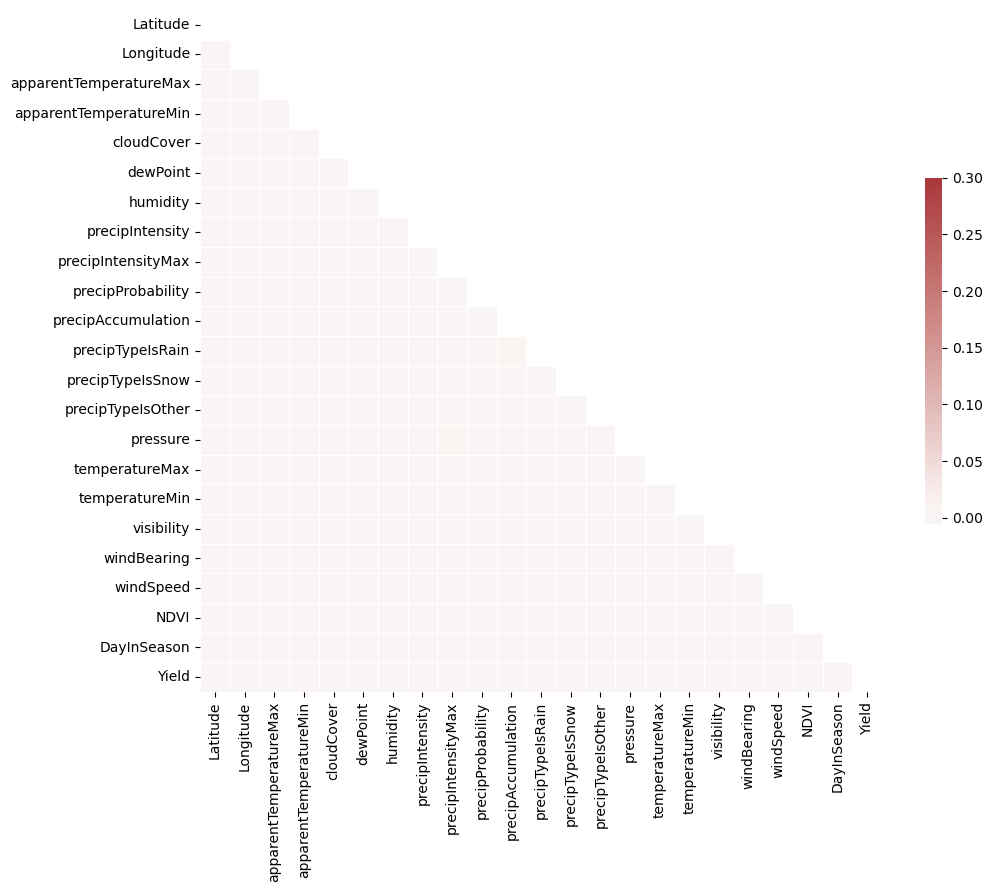

In [35]:
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(11, 9))

# Correct colormap
cmap = "vlag"

sns.heatmap(
    correlation_data,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.show()

### Wheat Yield Analysis

<Axes: xlabel='Yield', ylabel='Count'>

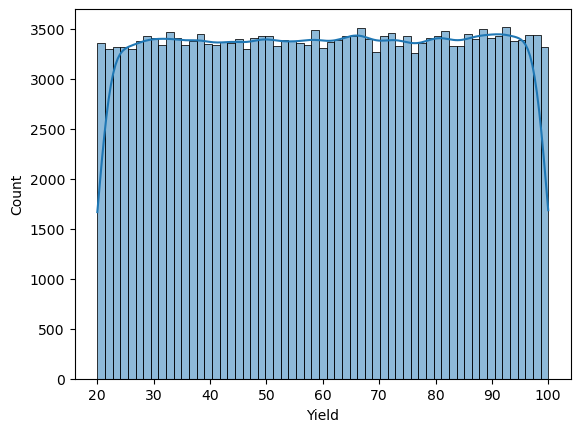

In [38]:
sns.histplot(data['Yield'],kde=True)

#### Observation
Yield is dependent on region and climate

Distribution is not normal

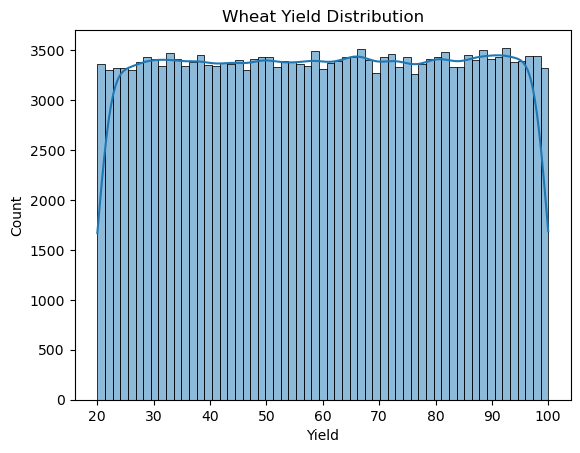

In [42]:
sns.histplot(data['Yield'],kde=True)
plt.title('Wheat Yield Distribution')
plt.show()

In [33]:
#df['Yield_log'] = np.log1p(df['Yield'])

## Spatial Exploratory Data Analysis

<Axes: >

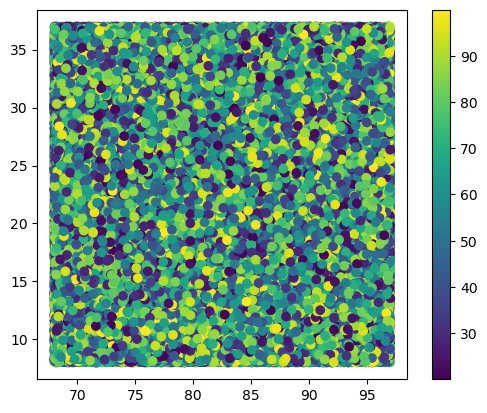

In [44]:
gddf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data.Longitude, data.Latitude)
)

gddf.plot(column='Yield', cmap='viridis', legend=True)

#### Observations
Equality exists in some regions while inequality is across some regions

productivity across region depending on weather

spatial autocorrelation

## Climate Vs Yield

<Axes: >

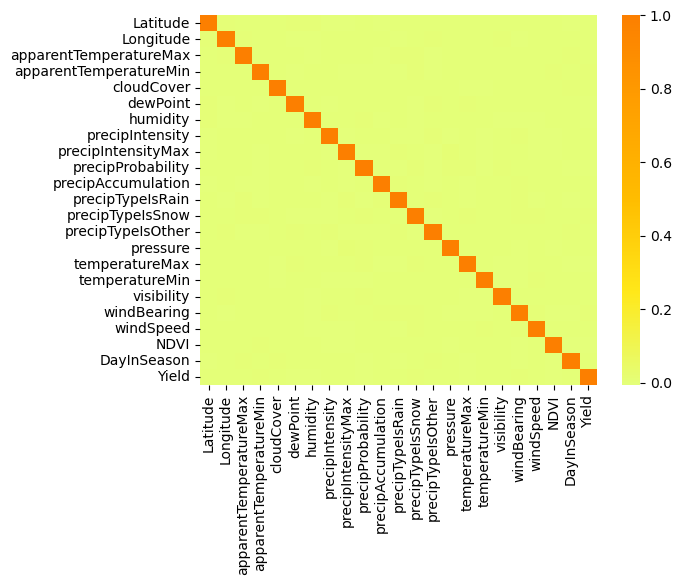

In [47]:
sns.heatmap(data.corr(), cmap='Wistia')

<Axes: xlabel='temperatureMax', ylabel='Yield'>

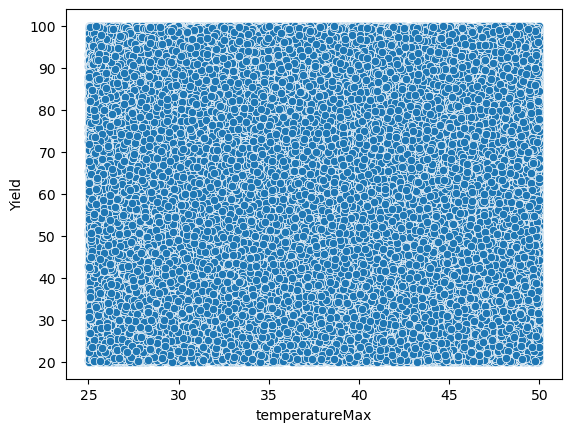

In [49]:
sns.scatterplot(x='temperatureMax', y='Yield', data=data)

In [51]:
#Top 5 features correlating with yield
yield_correlations = correlation_data['Yield'].sort_values(ascending=False)
display(yield_correlations.head(6))

Yield                     1.000000
windBearing               0.003377
precipTypeIsSnow          0.002629
apparentTemperatureMin    0.002509
windSpeed                 0.001262
visibility                0.001043
Name: Yield, dtype: float64

<Axes: xlabel='apparentTemperatureMin', ylabel='Yield'>

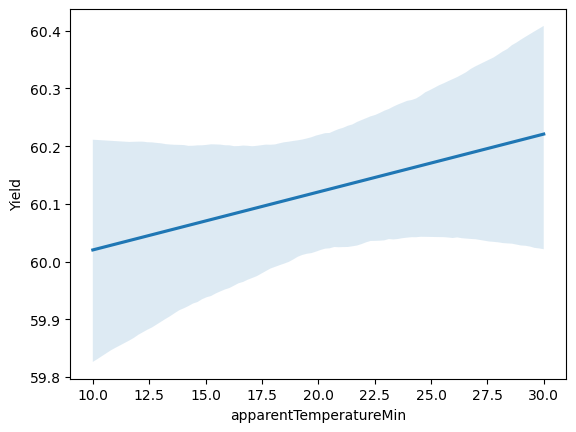

In [57]:
sns.regplot(x='apparentTemperatureMin', y='Yield', data=data, scatter=False)

#### Observation
The relationship is non linear, 

The higher the temperature the higher the yield

temperature range is optimal

### NDVI EDA

<Axes: xlabel='NDVI', ylabel='Yield'>

C:\Users\funmi\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\funmi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


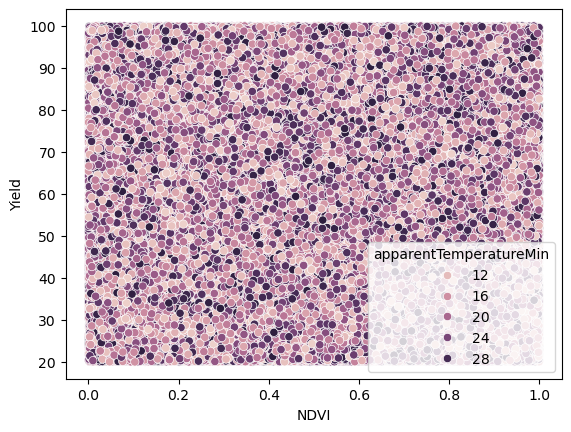

In [59]:
sns.scatterplot(x='NDVI',y='Yield',data=data, hue= "apparentTemperatureMin")

<Axes: xlabel='NDVI', ylabel='Yield'>

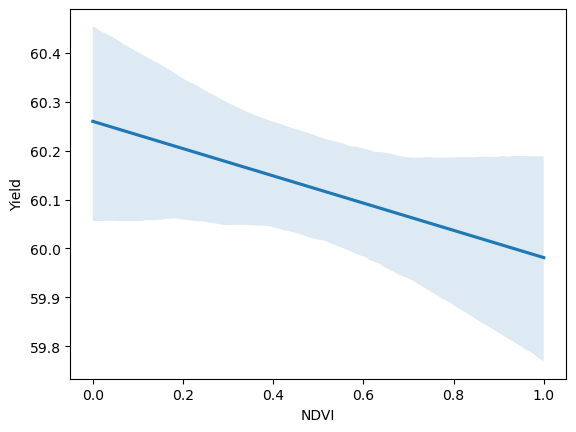

In [60]:
sns.regplot(x='NDVI',y='Yield',data=data, scatter=False)

C:\Users\funmi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


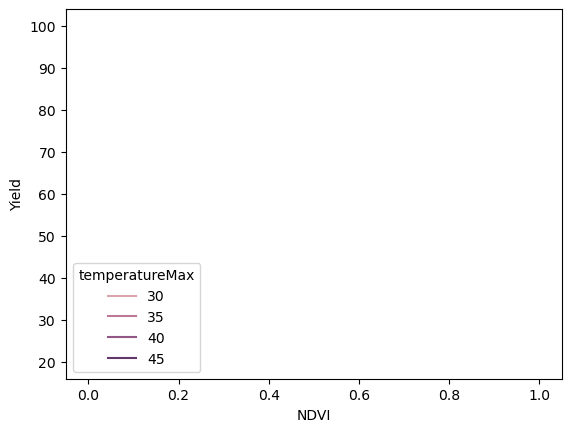

In [70]:
sns.lineplot(data=data, x="NDVI", y="Yield", hue = "temperatureMax")

plt.show()

In [ ]:
sns.boxplot(x='NDVI',y='Yield',data=data, hue="apparentTemperatureMin")

### Observations
positve correlation
Is the strongest and msot reliable predictor of yield


## Seasonality/Temporal EDA

In [ ]:
sns.lineplot(x='DayInSeason', y='Yield', data=data)

weather is important to growth stages and wheat yield is dependent on timing, 
the earlier stress or drought the larger the drop in yield

In [ ]:
sns.pairplot(df[['Yield','NDVI','TemperatureMax','Precipitation']])

In [ ]:
sns.pairplot(df[['Yield','NDVI','apparentTemperatureMin','Precipitation']])

### Correlation

In [ ]:
plt.figure(figsize(10,5))
sns.heatmap(data.corr(),cmap='olivedrab')
plt.title('Çorrelation Matrix')
plt.show()

### Outliers

In [ ]:
sns.scatterplot(x=data['Yield]')
plt.show()

### Feature importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

importances = model.feature_importances_

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

### DATA PREPARATION

In [ ]:
df = data.select_dtypes(include=[nplnumber])

In [ ]:
## There was no missing values in this data.

In [ ]:
#select yield as the target variable
X,y 
X= df.drop(['Yield'],axis=1)
y=df['Yield']

### PCA

### Model Trainng

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### RANDOM FOREST REGRESSION

In [ ]:
rf = RandomForestRegressor(n_estimator=1000)
rf.fit(X_train,y_train)
rf_y_pred = rf.predict(X_test)
Print("RF RMSE:", np.sqrt(mean_squared_error(y_test,rf_y_pred))

In [ ]:
rf.fit(X_train,y_train)
rf_y_pred = rf.predict(X_test)
Print("RF RMSE:", np.sqrt(mean_squared_error(y_test,rf_y_pred)))
print("RF R2:" r_score(y_test,y_pred_rf))

### XGBOOST

In [ ]:
xgb_model = xgb.XGBRegressor()
xg_model.fit(X_train,y_train)


In [ ]:
xgb_y_pred = xgb.predict(X_test)
Print("xgb RMSE:", np.sqrt(mean_squared_error(y_test,xgb_y_pred)))
print("XGB R2:" r_score(y_test,y_pred_rf))

### FEATURE IMPORTANCE

In [ ]:
 important_features = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

### EXPLAINABILITY (SHAP)

In [ ]:
# Creating explainer
explainer = shap.Explainer(xg_model)
explainer = shap.TreeExplainer(xg_model)

In [ ]:
# Compute SHAP values
shap_values = explainer.shap_values(X_test)

In [ ]:
# Summary plot
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Single prediction

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

Dependencies Plot

In [ ]:
shap.dependence_plot("Rainfall", shap_values, X_test)

In [ ]:
“SHAP was used to interpret the influence of climatic variables (e.g., rainfall, temperature) on crop yield predictions, improving model transparency for agricultural decision-making.”

### Geographical Analysis

In [ ]:
mport geopandas as gpd
gddf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(data.Longitude, d\ata.Latitude))
gddf.plot(column='Yield', legend=True)


In [ ]:
PCA

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel('Components')
# plt.ylabel('Explained Variance')
# plt.title('PCA Variance')
# plt.show()